## SVM - Support Vector Machines

SVM finds the optimal hyperplane that maximizes the margin between classes

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

In [5]:
# Load dataset
df = pd.read_csv("USA_Housing.csv")
print(df.head())

   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      79545.458574             5.682861                   7.009188   
1      79248.642455             6.002900                   6.730821   
2      61287.067179             5.865890                   8.512727   
3      63345.240046             7.188236                   5.586729   
4      59982.197226             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09     23086.800503  1.059034e+06   
1                          3.09     40173.072174  1.505891e+06   
2                          5.13     36882.159400  1.058988e+06   
3                          3.26     34310.242831  1.260617e+06   
4                          4.23     26354.109472  6.309435e+05   

                                             Address  
0  208 Michael Ferry Apt. 674\nLaurabury, NE 3701...  
1  188 Johnson Views Suite 079\nLake Kathleen, CA...  
2  9127 Eli

In [7]:
# Drop non-useful column if exists
if 'Address' in df.columns:
    df = df.drop('Address', axis=1)

X = df.drop('Price', axis=1)
y = df['Price']

In [8]:
# Convert price into 0 (low) and 1 (high)
y = (y > y.mean()).astype(int)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Basic SVM MODEL

In [11]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm = SVC(kernel='rbf')

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.906


In [12]:
## Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(SVC(), svm_params, cv=5)
svm_grid.fit(X_train_scaled, y_train)

best_svm = svm_grid.best_estimator_

y_pred_svm = best_svm.predict(X_test_scaled)

print("Best Parameters:", svm_grid.best_params_)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
SVM Accuracy: 0.907


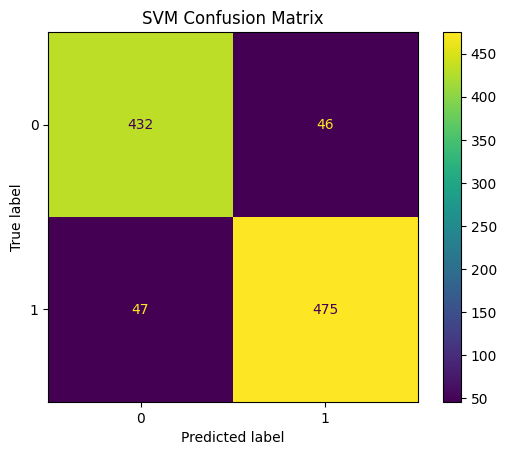

In [13]:
## CONFUSION MATRIX
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm)
plt.title("SVM Confusion Matrix")
plt.show()

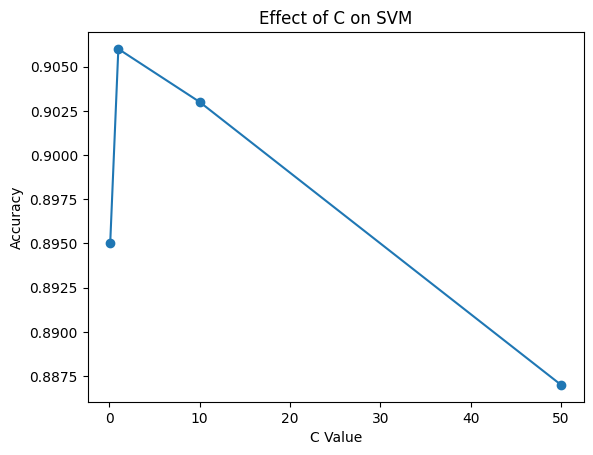

In [14]:
C_values = [0.1, 1, 10, 50]
accuracies = []

for c in C_values:
    model = SVC(C=c)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, preds))

plt.figure()
plt.plot(C_values, accuracies, marker='o')
plt.xlabel("C Value")
plt.ylabel("Accuracy")
plt.title("Effect of C on SVM")
plt.show()

In [15]:
# Prediction already done earlier
y_pred_svm = best_svm.predict(X_test_scaled)

svm_acc = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.907
